# Search: Solving a Maze Using a Goal-based Agent

Student Name: [Add your name]

I have used the following AI tools: [list tools]

I understand that my submission needs to be my own work: [your initials]

## Learning Outcomes

* Formulate search problems using key components like initial state, actions, and goal state in a deterministic, fully observable environment.
* Implement the search algorithm BFS for planning paths through mazes.
* Use visualization tools to represent maze paths and support debugging and analysis.

## Instructions

Total Points: Undergrads 10

Complete this notebook. Use the provided notebook cells and insert additional code and markdown cells as needed. Submit the notebook file and the completely rendered notebook with all outputs as a HTML file. 


## Introduction

In this exercise, we will implement the planning function for a type of goal-based agent called a __planning agent__. The planning function uses a map it is given to plan a path through the maze from the starting location $S$ to the goal location $G$. We will only focus on the planning function, so you do not need to implement an environment, just use the map to search for a path to solve the maze. 

Once the plan is made, the agent in a deterministic environment (i.e., the transition function is deterministic with the outcome of each state/action pair fixed and no randomness) can just follow the plan step-by-step and does not need to care about the percepts.
This is also called an **[open-loop system](https://en.wikipedia.org/wiki/Open-loop_controller).**
The execution phase is trivial and can be executed using a model-based reflex agent 
that ignores all percepts and just follows the plan. I will show you a short example, but you do not implement it in this exercise.

Given that the agent has a complete and correct map, the environment is **fully observable, discrete, deterministic, and known.** 
Remember:

* **Fully observable** means that the agent can see its state and what the available actions are. That means the **percepts contain the complete current state.**
Here, during planning, the agent always sees its x and y coordinates on the map and
also seeks when it has reached the goal state. 
* **Discrete** means that we have a **finite set of states.** The maze has a finite set 
of squares the agent can be in.
* **Deterministic** means that the **transition function contains no randomness.** An action in a state will always produce the same result. Going south from the start state always will lead to the same square.
* **Know** means that the agent **knows the complete transition function.** The 
agent has the map and therefore knows how its position changes when it walks in a direction.

Tree search algorithm implementations that you find online typically come from data structures courses and have a different aim than AI tree search. These algorithms assume that you already have a tree in memory. We are interested in dynamically creating a search tree with the aim of finding a good/the best path from the root note to the goal state. Follow the pseudo code presented in the text book (and replicated in the slides) closely. Ideally, we would like to search only a small part of the maze, i.e., create a search tree with as few nodes as possible. 

Several mazes for this exercise are stored as text files. We need to make sure that they are locally available.

In [13]:
import urllib.request
import os

def download(file, base_url):
    if not os.path.exists(file):
        urllib.request.urlretrieve(base_url + file, file)

base_url = "https://raw.githubusercontent.com/mhahsler/Introduction_to_Artificial_Intelligence/refs/heads/master/Search/"
download("maze_helper.py", base_url)

mazes = ["small_maze.txt", "large_maze.txt", "open_maze.txt", "empty_maze.txt"]
for maze in mazes:
    download(maze, base_url)

Here is the small example maze:

In [14]:
with open("small_maze.txt", "r") as f:
    maze_str = f.read()
print(maze_str)

XXXXXXXXXXXXXXXXXXXXXX
X XX        X X      X
X    XXXXXX X XXXXXX X
XXXXXX     S  X      X
X    X XXXXXX XX XXXXX
X XXXX X         X   X
X        XXX XXX   X X
XXXXXXXXXX    XXXXXX X
XG         XX        X
XXXXXXXXXXXXXXXXXXXXXX



**Note:** If you get an error here that the file cannot be found, then you need to download it. See [HOWTO Work on Assignments.](https://github.com/mhahsler/CS7320-AI/blob/master/HOWTOs/working_on_assignments.md)

## Parsing and pretty printing the maze

The maze can also be displayed in color using code in the module [maze_helper.py](maze_helper.py). The code parses the string representing the maze and converts it into a `numpy` 2d array which you can use in your implementation. Position are represented as a 2-tuple of the form `(row, col)`. 

In [ ]:
import maze_helper as mh

maze = mh.parse_maze(maze_str)

# look at a position in the maze by subsetting the 2d array
print("Position(0,0):", maze[0, 0])

# there is also a helper function called `look(maze, pos)` available
# which uses a 2-tuple for the position.
print("Position(8,1):", mh.look(maze, (8, 1)))

Position(0,0): X
Position(8,1): G


A helper function to visualize the maze is also available.

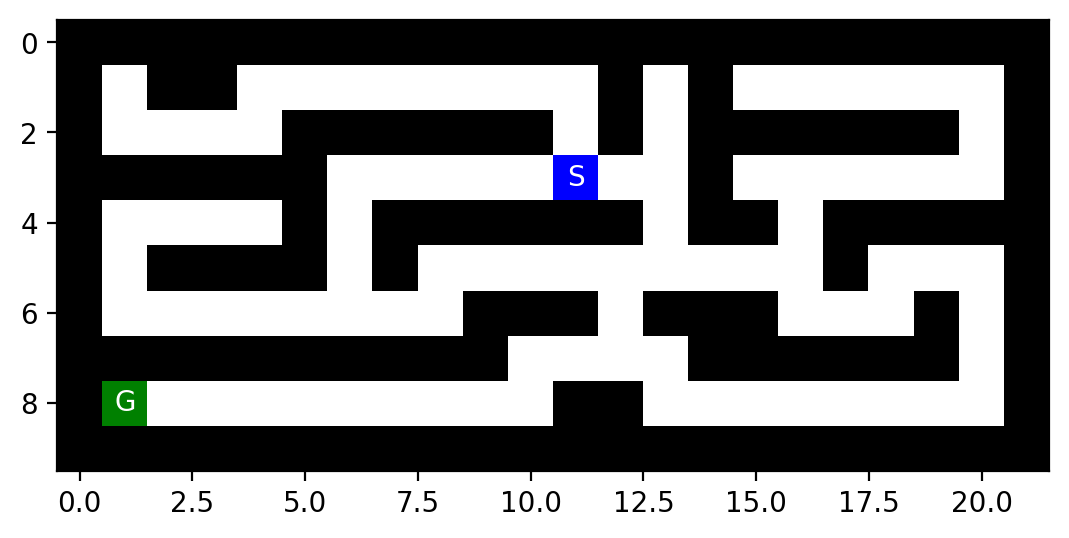

In [16]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
# use higher resolution images in notebooks

mh.show_maze(maze)

Find the `(x,y)` position of the start and the goal using the helper function `find_pos()`

In [17]:
print("Start location:", mh.find_pos(maze, what = "S"))
print("Goal location:", mh.find_pos(maze, what = "G"))

Start location: (np.int64(3), np.int64(11))
Goal location: (np.int64(8), np.int64(1))


Helper function documentation.

In [18]:
help(mh)

Help on module maze_helper:

NAME
    maze_helper

DESCRIPTION
    Code for the Maze Assignment
    Usage:
        import maze_helper as mh
        mh.show_some_mazes()

FUNCTIONS
    animate_maze(result, repeat=False)
        (Experimental) Build an animation from a list of mazes.

        Parameters:
            result: a list with the elements path, reached, actions and maze_anim with a list of maze arrays that contain what you want to visualize.
            repeat: if True, the animation will repeat.

    find_pos(maze, what='S')
        Find start/goal in a maze and returns the first one.
        Caution: there is no error checking!

        Parameters:
            maze: a array with characters produced by parse_maze()
            what: the letter to be found ('S' for start and 'G' for goal)

        Returns:
            a tupple (x, y) for the found position.

    look(maze, pos)
        Look at the label of a square with the position as an array of the form (x, y).

        Para

You will need to make a local copy of the module file [maze_helper.py](maze_helper.py) in the same folder where your notebook is.

## An Example for a Planning Agent

I will show you here how to implement a simple agent that uses a random plan. It will not solve the maze, but show you how the mechanics work.

First, we define a generic planning agent that fist plans, and then executes the plan step-by-step. 

In [19]:
class Planning_Agent:
    def __init__(self, maze, start, goal, planning_function):
        self.maze = maze
        self.start = start
        self.goal = goal
        self.planning_function = planning_function
        self.plan = None
        self.progress = None

    def act(self):
        # plan if no plan exists
        if self.plan is None:
            print("Planning...")
            self.plan = self.planning_function(self.maze, self.start, self.goal)
            self.progress = 0
        
        # check if plan is completed
        if self.progress >= len(self.plan):        
            raise Exception("Completed Plan. No more planned actions")
        
        # follow the plan
        action = self.plan[self.progress]
        print(f"Following plan... step {self.progress}: {action}")

        self.progress += 1
        return action

Next, we define the planning function. This function is what you will implement in this assignment.  

In [20]:
import numpy as np

def plan_random(maze, start, goal):
    """Create a random plan with 10 steps"""
    plan = np.random.choice(["N", "E", "S", "W"], size=10, replace=True).tolist()
    return plan

plan_random(maze, (1,1), (8,8))

['N', 'E', 'E', 'W', 'E', 'S', 'N', 'S', 'W', 'W']

This planning function is not great and will not produce a plan that solves the maze. Your planning functions will do better.

Finally, we can create the planning agent, give it the planning function and implement a simple environment that asks it 11 times for an action.

In [21]:
my_agent = Planning_Agent(maze, mh.find_pos(maze, what = "S"), mh.find_pos(maze, what = "G"), plan_random)

def environment(agent_function, steps):
    for _ in range(steps):
        try:
            agent_function()
        except Exception as e:
            print(f"Agent exception: {e}")

environment(my_agent.act, steps=11)

Planning...
Following plan... step 0: E
Following plan... step 1: W
Following plan... step 2: W
Following plan... step 3: W
Following plan... step 4: W
Following plan... step 5: N
Following plan... step 6: W
Following plan... step 7: N
Following plan... step 8: W
Following plan... step 9: W
Agent exception: Completed Plan. No more planned actions


Note: The agent and environment implementation above is just an illustration. You will only implement and experiment with different versions of the planning function.

## Tree structure

To use tree search, you will need to implement a tree data structure in Python. 
Here is an implementation of the basic node structure for the search algorithms (see Fig 3.7 on page 73). I have added a method that extracts the path from the root node to the current node. It can be used to get the path when the search is completed.

In [22]:
class Node:
    def __init__(self, pos, parent, action, cost):
        self.pos = tuple(pos)    # the state; positions are (row,col)
        self.parent = parent     # reference to parent node. None means root node.
        self.action = action     # action used in the transition function (root node has None)
        self.cost = cost         # for uniform cost this is the depth. It is also g(n) for A* search

    def __str__(self):
        return f"Node - pos = {self.pos}; action = {self.action}; cost = {self.cost}"
    
    def get_path_from_root(self):
        """returns nodes on the path from the root to the current node."""
        node = self
        path = [node]
    
        while not node.parent is None:
            node = node.parent
            path.append(node)
        
        path.reverse()
        
        return(path)

If needed, then you can add more fields to the class like the heuristic value $h(n)$ or $f(n)$.

Examples for how to create and use a tree and information on memory management can be found [here](../HOWTOs/trees.ipynb).

# Tasks

The goal is to:

1. Implement the following search algorithm for solving different mazes:
    - Breadth-first search (BFS)

2. Run each of the above algorithms on the 
    - [small maze](small_maze.txt), 
    - [large maze](large_maze.txt), 
    - [open maze](open_maze.txt), and
    - [empty maze](empty_maze.txt).

3. Display each solution by marking every maze square (or state) visited and the squares on the final path.

## General

1. Make sure that you use the latest version of this notebook.
2. Your implementation can use libraries like math, numpy, scipy, but not libraries that implement intelligent agents or complete search algorithms. Try to keep the code simple! In this course, we want to learn about the algorithms and we often do not need to use object-oriented design.
3. You notebook needs to be formatted professionally. 
    - Add additional markdown blocks for your description, comments in the code, add tables and use mathplotlib to produce charts where appropriate
    - Do not show debugging output or include an excessive amount of output.
    - Check that your submitted file is readable and contains all figures.
4. Document your code. Use comments in the code and add a discussion of how your implementation works and your design choices.

## Task 1: Defining the search problem and determining the problem size [2 Points]

Define the components of the search problem:

* Initial state
* Actions
* Transition model
* Goal state
* Path cost

Use verbal descriptions, variables and equations as appropriate. 

*Note:* You can switch the next block from code to Markdown and use formatting.

A state is represented as a 2-tuple $(row, columnx)$ square on the maze grid.

* Initial state: $s_0 = \text{start} = \text{mh.find\_pos}(\text{maze}, \text{'S'})$
* Actions ($A(s)$): {N,E,S,W} restricted only to legal moves that remain within grid boundaries and do not enter wall tiles ('X').
* Transition model: Function determining the next position $s'$ when executing action $a$ from state $s = (r, c)$:
    - N: $s' = (r - 1, c)$
    - S: $s' = (r + 1, c)$
    - W: $s' = (r, c - 1)$
    - E: $s' = (r, c + 1)$

  If an action leads into a wall or out of bounds, that action is unavailable.

* Goal state: the position `G = (row, col)` returned by `mh.find_pos(maze, "G")`. A state is a goal when its position equals `G`.
* Path cost ($c(s, a, s')$): Each legal step costs $1$, so $\text{cost}(\text{path}) = \text{length}(\text{path})$


Give some estimates for the problem size:

* $d$: depth of the optimal solution
* $m$: maximum depth of tree
* $b$: maximum branching factor

Describe how you would determine these values for a given maze.

* $d$ (Optimal solution depth): Length of the shortest path from `'S'` to `'G'`. For a particular maze, BFS can be used to find an optimal path, and its path length is `d`.
* $m$ (Maximum tree depth): Length of the longest simple path in the state space. With a reached set preventing revisited states, an agent cannot visit any state more than once. Thus, $m \le n - 1$, where $n$ is the total number of passable squares.
  
* $b$ (Maximum branching factor): Maximum number of legal successors from any passable square, where $b \le 4$ in a 4-connected grid. 
  Obtained by scanning every walkable cell and counting its non-wall N/E/S/W neighbors. 

## Task 2: Breadth-First Search [5 Points]

Implement this simple search strategies. Follow the pseudocode in the textbook/slides. You can use the tree structure shown above to extract the final path from your solution.

Read the following **important note** carefully:
* You can find maze solving implementations online that use the map to store information. While this is an effective idea for this two-dimensional navigation problem, it typically cannot be used for other search problems. Therefore, follow the textbook and **do not store information in the map.** Only store information in the tree created during search, and use the `reached` and `frontier` data structures where appropriate.


In [ ]:
from collections import deque

def get_neighbors(maze, pos):
    """
    Find valid neighboring positions from the current cell.
    Returns a list of tuples: [(action, (new_row, new_col)), ...]
    """
    r, c = pos
    moves = [
        ('N', (r - 1, c)),
        ('S', (r + 1, c)),
        ('W', (r, c - 1)),
        ('E', (r, c + 1)),
    ]
    neighbors = []
    rows, cols = maze.shape
    for action, (nr, nc) in moves:
        if 0 <= nr < rows and 0 <= nc < cols and maze[nr, nc] != 'X':
            neighbors.append((action, (nr, nc)))
    return neighbors

def bfs(maze, start, goal):
    """
    Breadth-First Search (BFS) algorithm.
    Uses a FIFO queue (frontier) and a reached set to track visited states.
    """
    start_pos = tuple(start)
    goal_pos = tuple(goal)
    
    root = Node(start_pos, None, None, 0)
    if start_pos == goal_pos:
        return {
            'path': [root],
            'actions': [],
            'reached': {start_pos},
            'path_length': 0,
            'nodes_expanded': 0
        }
    
    frontier = deque([root])  #FIFO queue
    reached = {start_pos}
    nodes_expanded = 0
    
    while frontier:
        node = frontier.popleft()
        nodes_expanded += 1
        
        for action, child_pos in get_neighbors(maze, node.pos):
            # Early Goal Test
            if child_pos == goal_pos:
                child_node = Node(child_pos, node, action, node.cost + 1)
                reached.add(child_pos)
                # Trace back path from root to goal via parent pointers
                full_path = child_node.get_path_from_root()
                # Extract the corresponding action sequence
                actions = [n.action for n in full_path if n.action is not None]

                return {
                    'path': full_path,
                    'actions': actions,
                    'reached': reached,
                    'path_length': len(actions),
                    'nodes_expanded': nodes_expanded
                }
                        
            if child_pos not in reached:
                reached.add(child_pos)
                child_node = Node(child_pos, node, action, node.cost + 1)
                frontier.append(child_node)
                
    return {
        'path': None,
        'actions': None,
        'reached': reached,
        'path_length': None,
        'nodes_expanded': nodes_expanded
    }

test_mazes = ["small_maze.txt", "large_maze.txt", "open_maze.txt", "empty_maze.txt"]
results = {}

print(f"{'Maze':<18} | {'Path Length':<12} | {'Nodes Expanded'}")
print("-" * 50)
for maze_file in test_mazes:
    with open(maze_file, "r") as f:
        m_str = f.read()
    current_maze = mh.parse_maze(m_str)
    start_pos = mh.find_pos(current_maze, what='S')
    goal_pos = mh.find_pos(current_maze, what='G')
    
    res = bfs(current_maze, start_pos, goal_pos)
    results[maze_file] = (current_maze, res)
    
    print(f"{maze_file:<18} | {str(res['path_length']):<12} | {res['nodes_expanded']}")

Maze               | Path Length  | Nodes Expanded
--------------------------------------------------
small_maze.txt     | 19           | 90
large_maze.txt     | 210          | 617
open_maze.txt      | 54           | 679
empty_maze.txt     | 14           | 92


The result of the planning function is a sequence of actions. Fill out the following table:


| maze | path length | # of nodes expanded |
|-----------|-----------|------------------|
| small     |     19    |        90        |
| large     |    210    |       617        |
| open      |     54    |       679        |
| empty     |     14    |       92         |

Visualize the found path for each maze. You can look at the `show_maze()` function in [maze_helper.py](maze_helper.py) to see how you can visualize the path.

Visualization: small_maze.txt


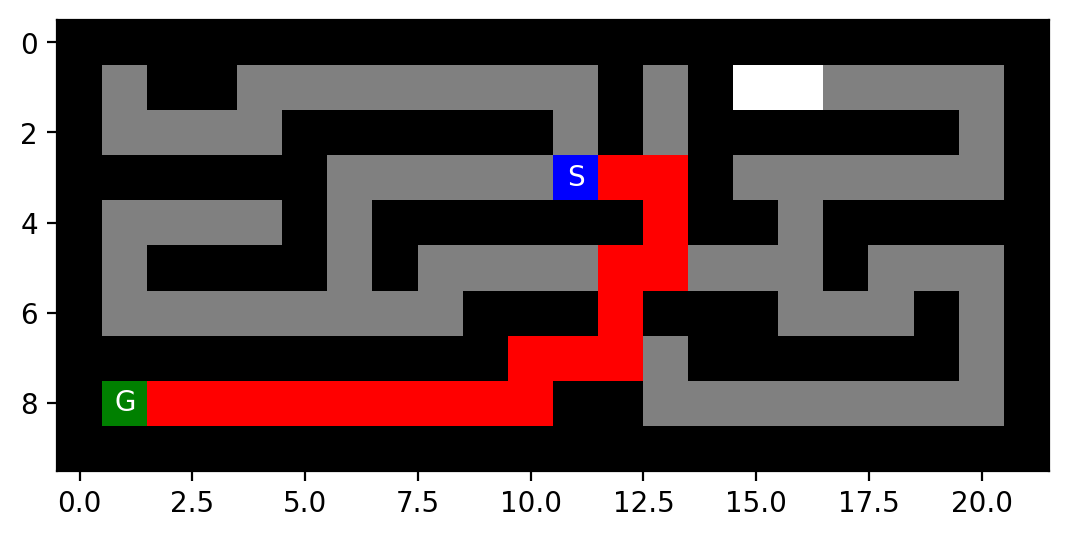

Visualization: large_maze.txt


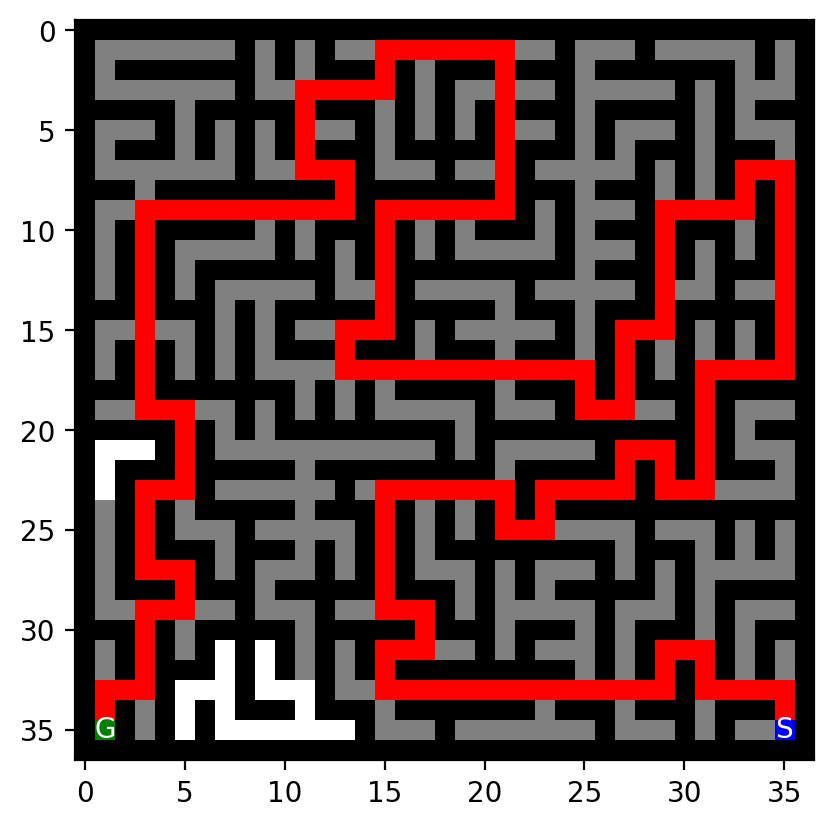

Visualization: open_maze.txt


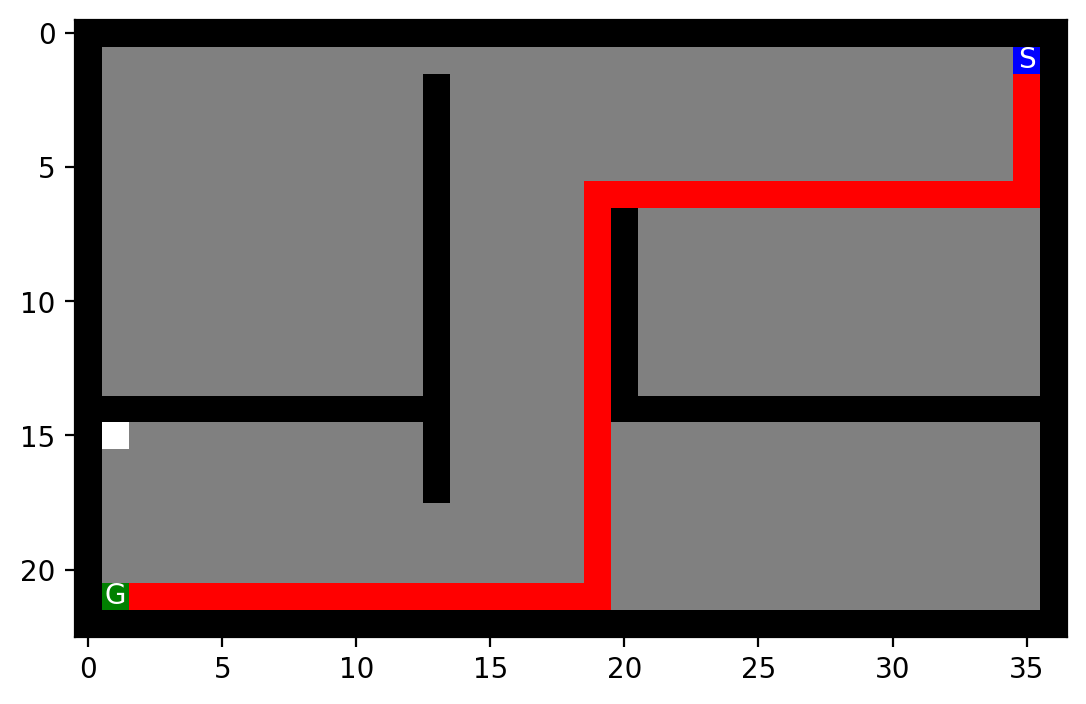

Visualization: empty_maze.txt


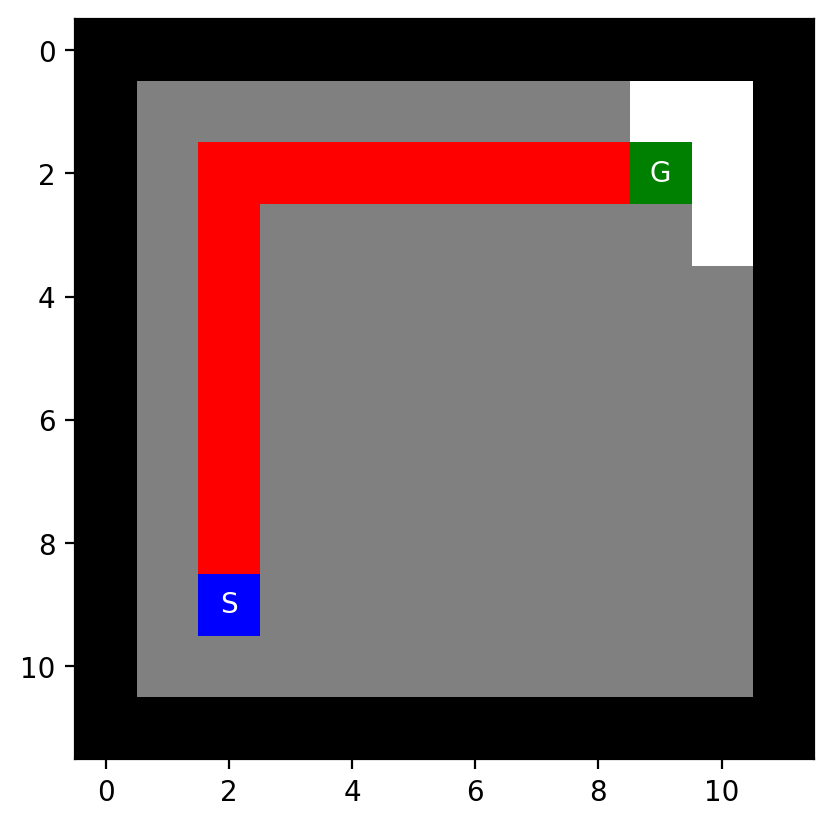

In [ ]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'
import matplotlib.pyplot as plt

def show_solution(maze, result):
    viz_maze = maze.copy()
    for r, c in result['reached']:
        if viz_maze[r, c] == ' ':
            viz_maze[r, c] = '.'
            
    if result['path'] is not None:
        for node in result['path'][1:-1]:
            viz_maze[node.pos] = 'P'
            
    mh.show_maze(viz_maze)

for maze_file, (current_maze, res) in results.items():
    print(f"Visualization: {maze_file}")
    show_solution(current_maze, res)
    plt.show()

# Task 3: Discussion [3 Points] 

Is your implementation complete and optimal? Explain why. What is the time and space complexity of each of **your** implementation?

* **Completeness:** Yes, it is complete. The state space is finite, and the `reached` set prevents cycles and infinite loops, ensuring the goal is always found if a path exists.
* **Optimality:** Yes, it is optimal. Since all actions have a uniform step cost ($c = 1$), BFS explores states level-by-level in increasing order of depth, guaranteeing that the first path found is the shortest.
* **Time Complexity:** $O(b^d)$. In the worst case, BFS must generate nodes across all levels up to depth $d$. In graph search with a `reached` set, the runtime is also bounded by $O(V + E)$, where $V \le n$ is the number of passable squares
* **Space Complexity:** $O(b^d)$, because all generated nodes must be stored in memory within the `frontier` queue and the `reached` set.

How would the planning improve if you use informed search with A* search and the Euclidean distance to the goal as the heuristic? What would the algorithm do differently?

* **Evaluation Function Difference:**
  - BFS uses an uninformed strategy $f(n) = g(n)$ (expanding strictly based on step count/depth), spreading blindly in all open directions like an expanding wave.
  - A\* uses an informed evaluation function $f(n) = g(n) + h(n)$, which factors in both the actual cost so far $g(n)$ and the heuristic estimate $h(n)$ to the goal.

* **What A\* would do differently:**
  1. **Goal-directed search:** Instead of a FIFO queue, A\* uses a min-priority queue ordered by $f(n)$. States closer to the goal coordinates have a smaller $h(n)$ value and are prioritized, steering the search beam directly toward the goal rather than exploring useless branches[cite: 5].
  2. **Reduced node expansions:** The heuristic prunes branches leading away from the goal. In open or empty mazes, BFS floods the entire room, whereas A\* heads almost directly toward the target, significantly reducing the number of expanded nodes.
  3. **Preserving optimality:** The straight-line Euclidean distance $h(n) = \sqrt{(r_n - r_g)^2 + (c_n - c_g)^2}$ is admissible ($h(n) \le h^*(n)$) and consistent on a grid. Therefore, A\* is guaranteed to return the exact same optimal path length as BFS while saving time and memory

Your BFS implementation works fine to solve small mazes. Why would it not work for larger problems with millions of states and 100s of actions? What algorithm could be used then?

* **Why BFS fails on massive problem spaces:**
  1. **Memory exhaustion (Space bottleneck):** With a large branching factor (e.g., $b = 100$), storing the frontier at depth $d = 8$ would require storing $b^d = 100^8 = 10^{16}$ nodes in memory, causing an immediate Out-Of-Memory (OOM) crash.
  2. **Exponential execution time:** Blind exploration without domain heuristics forces BFS to explore vast numbers of irrelevant states before stumbling upon the goal[cite: 5].

* **Alternative algorithms that could be used:**
  1. **Iterative Deepening Search (IDS):** Guarantees optimality like BFS while consuming only linear memory $O(b \cdot d)$ of DFS.
  2. **A\*:** Reduces the effective search tree drastically using an informative heuristic.
